# 04 · How the ensemble mergers actually combine the backends

Notebook 03 *ran* the fusion modes; this one opens them up and shows the
**merging mechanics**, with a focus on the three you asked about — the **EKF**,
the **RL** trust gate, and the **JEPA** perception model.

### The layered mental model

The six baselines are the inputs. The `--fusion` flag picks how they are merged,
and the modes fall into two families:

- **Pose-space combiners** (no filter): `confidence_weighted` blends the poses;
  `winner_takes_healthy` switches to the single healthiest backend.
- **Filter-based merger**: `weighted_ekf` runs a real error-state EKF.
  `rl_gated` is *the same EKF* with a learned per-backend **trust** knob on top.

**JEPA is not a merger.** It is a self-supervised perception model that produces
*features* (surprise, embedding speed) consumed by the RL policy. So the learned
stack is:

> **EKF** (does the estimating) + **RL policy** (decides how much to trust each
> backend each control period) + **JEPA** (tells the policy how trustworthy the
> visual world looks right now).

| Mode | Mechanism | Estimator? | Learned? | JEPA? |
| --- | --- | --- | --- | --- |
| `confidence_weighted` | convex blend by reliability×confidence×health | no | no | no |
| `winner_takes_healthy` | follow healthiest backend (hysteresis) | no | no | no |
| `weighted_ekf` | error-state EKF + gates + inverse-variance updates | **yes** | no | no |
| `rl_gated` | same EKF; PPO sets per-backend trust | **yes** | **yes** | optional |

We drive the real fusion code the whole way through.

In [1]:
# --- Notebook bootstrap: put the src/ package on the path, pick the dataset ---
import sys, time, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 92

DATA = ROOT / "data"
CANDIDATES = ["indoor_flying1_5s20s_img.h5", "indoor_flying1_5s20s.h5"]
SEQ_PATH = next((DATA / c for c in CANDIDATES if (DATA / c).exists()), None)
assert SEQ_PATH is not None, (
    "No hexacopter slice found under data/. Regenerate one (needs the MVSEC bags) with:\n"
    "  uv run python scripts/convert_mvsec_bag_to_h5.py \\\n"
    "    --data-bag data/indoor_flying1_data.bag --gt-bag data/indoor_flying1_gt.bag \\\n"
    "    --output data/indoor_flying1_5s20s_img.h5 --start-sec 5 --duration-sec 15 --include-images"
)
print("Repo root :", ROOT)
print("Sequence  :", SEQ_PATH.name)

Repo root : /home/jovyan/event-based-vio
Sequence  : indoor_flying1_5s20s_img.h5


In [2]:
import types
from nav_benchmark.datasets.mvsec import load_mvsec_sequence
from nav_benchmark.events.representations import ensure_event_frames
from nav_benchmark.run import _imu_only_config_for_sequence, _ensemble_baselines
from nav_benchmark.evaluation.harness import load_ground_truth_trajectory
from nav_benchmark.evaluation.metrics import evaluate_trajectory, EvalConfig

# nav_benchmark.evaluation.plots forces a headless Agg backend at import time;
# re-assert inline so figures render in the notebook.
get_ipython().run_line_magic("matplotlib", "inline")

seq = load_mvsec_sequence(SEQ_PATH)
ensure_event_frames(seq, window_sec=0.05)
args = types.SimpleNamespace(dataset="mvsec", input=str(SEQ_PATH),
                             sequence="indoor_flying1", event_window_ms=50.0)
imu_cfg = _imu_only_config_for_sequence(args, seq)
gt = load_ground_truth_trajectory(SEQ_PATH)
cfg = EvalConfig()

t0 = time.perf_counter()
baselines, _ = _ensemble_baselines(args, seq, None, imu_cfg)   # the 6 merge inputs
print(f"Prepared {len(baselines)} backend inputs in {time.perf_counter()-t0:.1f} s")

def ate(traj):
    return evaluate_trajectory(traj, gt, cfg).metrics.ate_rmse

Prepared 6 backend inputs in 32.8 s


## A · Pose-space combiners — the blend weight, opened up

`confidence_weighted` gives each backend a weight
`static_reliability × confidence × health_multiplier`, then normalizes across
backends and blends the poses. Let's expose those intermediate quantities at one
timestamp using the library's own helpers.

In [3]:
from nav_benchmark.ensemble.confidence_weighted import (
    EnsembleConfig, ENSEMBLE_METHODS, _sample_trajectories, _raw_weight_columns, fuse_trajectories,
)

ecfg = EnsembleConfig()
cw = fuse_trajectories(baselines, config=ecfg)

# Reproduce the weight recipe at one instant (mid-run) from the library internals.
k = len(cw.timestamps) // 2
t_star = cw.timestamps[k]
sampled = _sample_trajectories(baselines, np.array([t_star]))
raw = _raw_weight_columns(sampled, ecfg)                     # static x conf x health
total = sum(float(raw[m][0]) for m in raw)
rows = []
for m in ENSEMBLE_METHODS:
    s = sampled[m]
    rows.append({
        "backend": m,
        "static_reliability": ecfg.static_weights.get(m, 0.0),
        "confidence": round(float(s.confidence[0]), 3),
        "health": str(s.health[0]),
        "raw = s*c*h": round(float(raw[m][0]), 3),
        "blend_weight": round(float(raw[m][0]) / total, 3) if total else 0.0,
    })
print(f"Blend weights at t = {t_star - cw.timestamps[0]:.2f} s (sum of blend_weight = 1):")
pd.DataFrame(rows).set_index("backend")

Blend weights at t = 7.50 s (sum of blend_weight = 1):


,static_reliability,confidence,health,raw = s*c*h,blend_weight
backend,,,,,
imu_only,0.10,1.000,LOST,0.000,0.000
rgb_vo,0.25,0.999,OK,0.250,0.137
event_vo,0.15,0.875,OK,0.131,0.072
event_imu,0.50,0.725,OK,0.363,0.200
image_imu,0.50,1.000,OK,0.500,0.275
multimodal_vio,0.60,0.956,OK,0.574,0.316


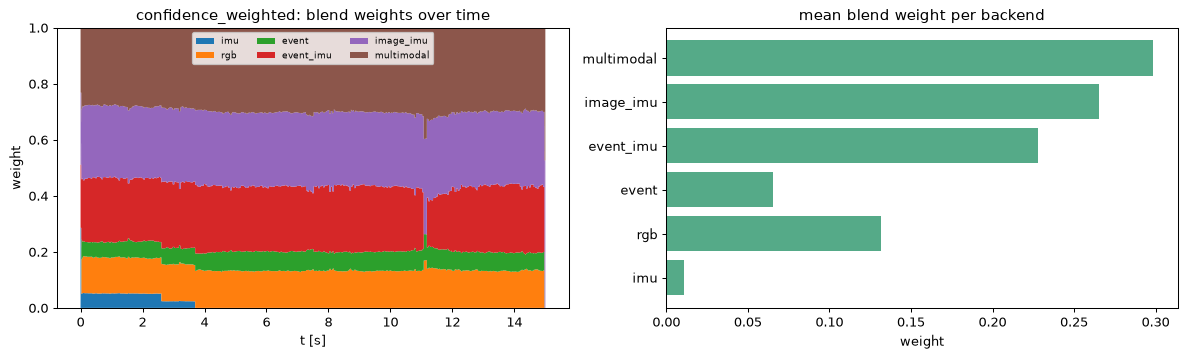

winner_takes_healthy uses the SAME raw scores but hands 100% weight to the argmax backend, switching only past a hysteresis margin (see notebook 03).


In [4]:
# The same weights over the whole run + the mean contribution of each backend.
from nav_benchmark.ensemble.confidence_weighted import ENSEMBLE_WEIGHT_COLUMNS
cols = list(ENSEMBLE_WEIGHT_COLUMNS.values())
names = [c.replace("w_", "") for c in cols]
W = np.vstack([cw.extra_columns[c] for c in cols])
t_rel = cw.timestamps - cw.timestamps[0]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
a0.stackplot(t_rel, W, labels=names); a0.set_title("confidence_weighted: blend weights over time")
a0.set_xlabel("t [s]"); a0.set_ylabel("weight"); a0.set_ylim(0, 1); a0.legend(ncol=3, fontsize=7, loc="upper center")
a1.barh(names, W.mean(axis=1), color="#5a8"); a1.set_title("mean blend weight per backend"); a1.set_xlabel("weight")
plt.tight_layout(); plt.show()
print("winner_takes_healthy uses the SAME raw scores but hands 100% weight to the argmax backend, "
      "switching only past a hysteresis margin (see notebook 03).")

## B · The EKF merger — a real recursive filter

`weighted_ekf` is the only mode that estimates state. It is a **15-state
error-state EKF** — `[position, velocity, orientation, accel-bias, gyro-bias]`:

1. **Propagate** the raw IMU (`imu_only` is the backbone, so the *other five*
   backends are the measurements).
2. Each backend pose is an **absolute-position measurement** that must clear a
   cascade of **hard gates**: health → confidence → timestamp-age →
   motion-sanity → Mahalanobis χ².
3. Surviving updates are weighted by a **confidence→σ** map (high confidence ⇒
   tight σ ⇒ big correction), contributing ∝ 1/σ².

First the confidence→σ curve, then the gate cascade as a funnel.

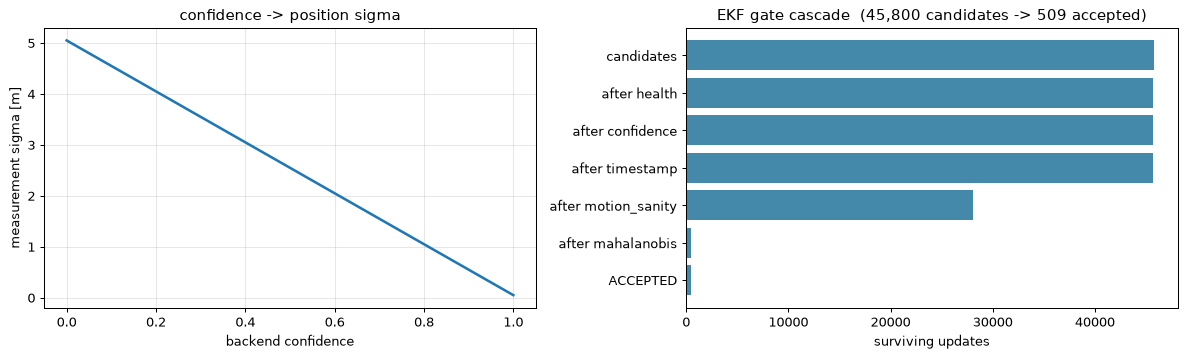

per-backend accepted: {'event_imu': 328, 'image_imu': 97, 'multimodal_vio': 81, 'event_vo': 1, 'rgb_vo': 2}


In [5]:
from nav_benchmark.ensemble.ekf import EkfConfig
from nav_benchmark.ensemble.fusion import run_weighted_ekf_fusion, EkfFusionConfig
from nav_benchmark.ensemble.gating import confidence_to_position_sigma

ekf_cfg = EkfFusionConfig(ekf=EkfConfig(gravity=imu_cfg.gravity))
init = dict(initial_position=imu_cfg.initial_position, initial_velocity=imu_cfg.initial_velocity,
            initial_orientation_xyzw=imu_cfg.initial_orientation)
measurements = {m: t for m, t in baselines.items() if m != "imu_only"}   # 5 backends

ekf_traj, records = run_weighted_ekf_fusion(seq.imu, measurements, config=ekf_cfg, **init)

# confidence -> sigma mapping used to weight each accepted update
conf = np.linspace(0, 1, 100)
sig = [confidence_to_position_sigma(c, ekf_cfg.sigma_position_min, ekf_cfg.sigma_position_range) for c in conf]

# Gate cascade: reasons are recorded for the FIRST gate a candidate fails.
from collections import Counter
rej = Counter(r.reason for r in records if not r.accepted)
order = ["health_gate", "confidence_gate", "timestamp_gate", "motion_sanity_gate", "mahalanobis_gate"]
total = len(records)
survivors, labels, n = [total], ["candidates"], total
for g in order:
    n -= rej.get(g, 0); survivors.append(n); labels.append("after " + g.replace("_gate", ""))
survivors.append(sum(r.accepted for r in records)); labels.append("ACCEPTED")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
a0.plot(conf, sig, lw=2); a0.set_title("confidence -> position sigma"); a0.set_xlabel("backend confidence")
a0.set_ylabel("measurement sigma [m]"); a0.grid(alpha=0.3)
a1.barh(range(len(survivors)), survivors, color="#48a")
a1.set_yticks(range(len(labels))); a1.set_yticklabels(labels); a1.invert_yaxis()
a1.set_title(f"EKF gate cascade  ({total:,} candidates -> {survivors[-1]:,} accepted)"); a1.set_xlabel("surviving updates")
plt.tight_layout(); plt.show()
print("per-backend accepted:", dict(Counter(r.method for r in records if r.accepted)))

## C · The RL merger — the same EKF with a learned trust dial

`rl_gated` keeps that exact EKF and adds a policy that outputs a per-backend
**trust ∈ [0,1]** every control period. Trust multiplies the backend's
confidence *before* the confidence→σ map; `trust < 0.05` excludes the
measurement with reason `policy_gate`. Two guarantees:

- **Exact parity:** trust ≡ 1 reproduces `weighted_ekf` bit-for-bit.
- **Hard gates stay on:** trust can only make an update count *less*; it can
  never push a gate-failing update into the filter.

We drive the fusion core directly (no trained checkpoint needed) to prove parity,
then hand-set a trust vector to see the dial move.

149 control steps @ 100 ms.  trust=1 vs weighted_ekf: max |position diff| = 0.00e+00 m  (ATE 141.302 == 141.302)


trust(event_imu)=0 -> 3,893 'policy_gate' exclusions;  ATE 141.3 m -> 73.3 m


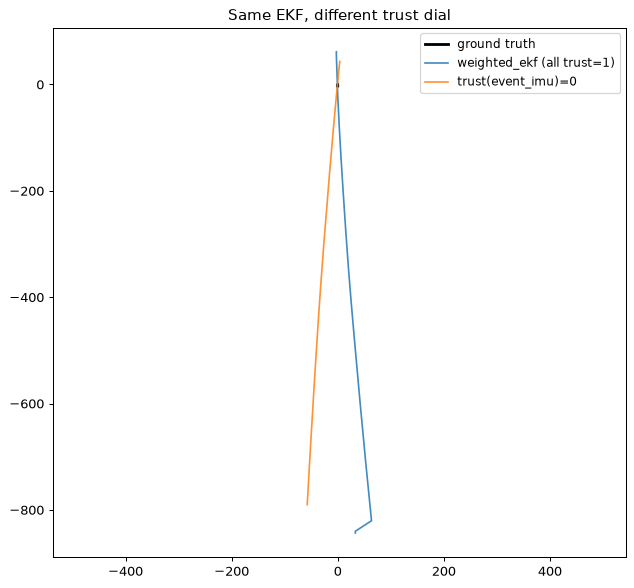

In [6]:
from nav_benchmark.ensemble.rl_gated import GatedEkfFusionCore, RlGatedFusionConfig, REASON_POLICY
rl_cfg = RlGatedFusionConfig(base=ekf_cfg, control_period_sec=0.10, min_trust_to_apply=0.05)
methods = sorted(measurements)

# (1) PARITY: drive every control step with trust = 1 for all backends.
core = GatedEkfFusionCore(seq.imu, measurements, config=rl_cfg, **init)
for _ in range(core.num_steps):
    core.step(np.ones(len(methods)))
parity_traj, _ = core.result()
print(f"{core.num_steps} control steps @ 100 ms.  trust=1 vs weighted_ekf: "
      f"max |position diff| = {np.max(np.abs(parity_traj.positions - ekf_traj.positions)):.2e} m  "
      f"(ATE {ate(parity_traj):.3f} == {ate(ekf_traj):.3f})")

# (2) INTERVENTION: zero the trust on the drift-prone event_imu backend.
core2 = GatedEkfFusionCore(seq.imu, measurements, config=rl_cfg, **init)
tvec = np.ones(len(methods)); tvec[methods.index("event_imu")] = 0.0
for _ in range(core2.num_steps):
    core2.step(tvec)
gated_traj, gated_records = core2.result()
pg = sum(1 for r in gated_records if r.reason == REASON_POLICY)
print(f"trust(event_imu)=0 -> {pg:,} 'policy_gate' exclusions;  ATE {ate(ekf_traj):.1f} m -> {ate(gated_traj):.1f} m")

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(gt.positions[:, 0], gt.positions[:, 1], "k-", lw=2.2, label="ground truth")
for name, tr in [("weighted_ekf (all trust=1)", ekf_traj), ("trust(event_imu)=0", gated_traj)]:
    est = evaluate_trajectory(tr, gt, cfg).aligned_estimate.positions
    ax.plot(est[:, 0], est[:, 1], lw=1.3, alpha=0.85, label=name)
ax.axis("equal"); ax.set_title("Same EKF, different trust dial"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

On this slice, *learning* to distrust the drift-prone `event_imu` nearly halves
ATE — that per-backend trust assignment is exactly what the PPO policy is trained
to discover (here we set it by hand).

### What the policy observes

The trust decision for control step *k* is a causal, bounded feature vector built
from step *k−1*: per-backend `[available, mean_confidence, frac_degraded,
frac_failed, innovation, mahalanobis, staleness, accept_ratio]`, plus globals
`[ekf_sigma, speed, progress, prev_mean_trust]`, plus (optionally) 3 JEPA
features. That is what a trained network maps to trust.

In [7]:
from nav_benchmark.rl.features import (
    FeatureConfig, feature_names, initial_observation, build_observation, observation_dim,
)
fc = FeatureConfig(methods=tuple(methods), include_jepa=False)
fcj = FeatureConfig(methods=tuple(methods), include_jepa=True)
print(f"observation dim: {observation_dim(fc)} (no JEPA)  ->  {observation_dim(fcj)} (+3 JEPA features)")

core3 = GatedEkfFusionCore(seq.imu, measurements, config=rl_cfg, **init)
summary = core3.step(np.ones(len(methods)))            # run one control window
obs = build_observation(fc, summary, progress=0.0, prev_trusts=np.ones(len(methods)))
names = feature_names(fc)
# Show the per-backend feature block the policy reads.
per = 8
blocks = {m: obs[i * per:(i + 1) * per] for i, m in enumerate(methods)}
feat_labels = [n.split(".", 1)[1] for n in names[:per]]
pd.DataFrame(blocks, index=feat_labels).round(3)

observation dim: 44 (no JEPA)  ->  47 (+3 JEPA features)


,event_imu,event_vo,image_imu,multimodal_vio,rgb_vo
available,1.000,1.000,1.000,1.000,1.000
mean_confidence,0.725,0.833,0.821,0.751,0.984
frac_degraded,0.235,0.000,0.284,0.245,0.000
frac_failed,0.000,0.000,0.000,0.000,0.000
innovation,0.001,0.007,0.005,0.006,0.010
mahalanobis,0.000,0.001,0.034,0.001,0.085
staleness,0.000,0.015,0.001,0.004,0.008
accept_ratio,1.000,0.500,0.941,0.794,0.667


### Why confidence alone isn't enough — the "confident bias" case

A backend can **drift while still reporting high confidence** (a sensor that has
silently lost lock but doesn't know it). A confidence-weighted merger trusts the
number and gets fooled; only *disagreement* features (innovation, cross-backend
agreement) reveal it. The RL trainer injects exactly this perturbation. Here we
apply it and show the tell: the output drifts but the reported confidence stays
flat.

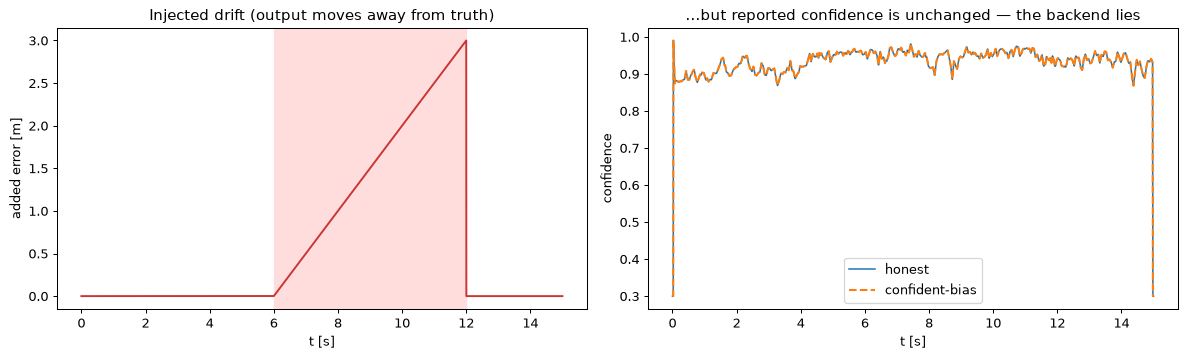

A confidence-weighted merger sees identical confidence in both cases. The policy must catch the
drift from the EKF *innovation* feature instead — which is why trust gating needs learning, not a rule.


In [8]:
from nav_benchmark.rl.perturb import BackendPerturbation, apply_perturbations, KIND_CONFIDENT_BIAS

honest = measurements["multimodal_vio"]
t_lo = honest.timestamps[0] + 0.40 * (honest.timestamps[-1] - honest.timestamps[0])
t_hi = honest.timestamps[0] + 0.80 * (honest.timestamps[-1] - honest.timestamps[0])
liar = apply_perturbations(honest, [BackendPerturbation(
    method="multimodal_vio", kind=KIND_CONFIDENT_BIAS,
    t_start=t_lo, t_end=t_hi, magnitude_m=3.0, direction=(1.0, 1.0, 0.0), seed=1)])

t_rel = honest.timestamps - honest.timestamps[0]
offset = np.linalg.norm(liar.positions - honest.positions, axis=1)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
a0.plot(t_rel, offset, color="#c33"); a0.axvspan(t_lo - honest.timestamps[0], t_hi - honest.timestamps[0], color="#fdd")
a0.set_title("Injected drift (output moves away from truth)"); a0.set_xlabel("t [s]"); a0.set_ylabel("added error [m]")
a1.plot(t_rel, honest.confidence, label="honest", lw=1.2)
a1.plot(t_rel, liar.confidence, "--", label="confident-bias", lw=1.6)
a1.set_title("...but reported confidence is unchanged — the backend lies")
a1.set_xlabel("t [s]"); a1.set_ylabel("confidence"); a1.legend()
plt.tight_layout(); plt.show()
print("A confidence-weighted merger sees identical confidence in both cases. The policy must catch the")
print("drift from the EKF *innovation* feature instead — which is why trust gating needs learning, not a rule.")

## D · JEPA — the perception features that feed the policy

The `rl_gated` observation can be extended with 3 features from **JEPA**, a
self-supervised scene model: `rgb_surprise`, `event_surprise`, and
`embedding_speed`. Surprise is the error of an ego-motion-conditioned predictor
on the next frame's embedding — high when the visual stream stops behaving
predictably — so the policy can pre-emptively lower trust *before* a bad update
reaches the filter. That grows the observation from 44 to 47 features.

JEPA is a perception model, **not** a merger, so it gets its own deep-dive:
**[`05_jepa_perception.ipynb`](05_jepa_perception.ipynb)** builds JEPA-lite end to
end (frames → patches → ego-conditioning → training → surprise/embedding signals)
and shows both the local and pretrained-embedding paths.

## Summary

- **Pose-space combiners** merge in pose space: `confidence_weighted` blends by
  `reliability×confidence×health`; `winner_takes_healthy` switches to the argmax.
- **The EKF merger** is the real estimator — IMU propagation + a hard gate
  cascade + inverse-variance updates. It rejects the large majority of candidate
  measurements; that gating is the safety mechanism.
- **The RL merger is not a different estimator** — it is the same EKF with a
  learned per-backend trust knob (trust≡1 ⇒ identical). Trust only ever
  *downweights/excludes*; the hard gates always hold. It targets the
  confident-bias case a fixed confidence rule can't.
- **JEPA is not a merger** — it is a perception model whose surprise/embedding
  signals become extra policy features, so the trust decision can react to how
  reliable the visual world currently looks.

Train and run the learned stack end-to-end:

```bash
uv run python -m nav_benchmark train-jepa --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output runs/jepa.pt
uv run python -m nav_benchmark train-rl   --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output-dir runs/rl --jepa runs/jepa.pt
uv run python -m nav_benchmark run --method ensemble --fusion rl_gated \
    --dataset mvsec --sequence indoor_flying1 --input data/indoor_flying1_5s20s_img.h5 \
    --policy runs/rl/policy_best.pt --jepa runs/jepa.pt --evaluate
```

Design details and guarantees: `docs/rl-ensemble.md`.